In [40]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt


In [4]:
# Load the Excel dataset and read all sheets
file_path = "../data/raw/online_retail_II.xlsx"

sheets = pd.read_excel(file_path, sheet_name=None)

print(sheets.keys())

dict_keys(['Year 2009-2010', 'Year 2010-2011'])


In [5]:
for name, data in sheets.items():
    print(f"\n{name}")
    print("Shape:", data.shape)
    print(data.columns.tolist())


Year 2009-2010
Shape: (525461, 8)
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

Year 2010-2011
Shape: (541910, 8)
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [6]:
# Combine the two sheets into a single DataFrame
df = pd.concat(sheets.values(), ignore_index=True)

print("Combined shape:", df.shape)
print(df.head())

Combined shape: (1067371, 8)
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom  


In [7]:
output_path = "../data/raw/online_retail_II.csv"

df.to_csv(output_path, index=False)

print(f"Saved to: {output_path}")

Saved to: ../data/raw/online_retail_II.csv


In [ ]:
# Load the raw transaction dataset

# file_path = "../data/raw/online_retail_II.csv"

# df = pd.read_csv(file_path)

In [8]:
# Check missing values in each column

missing = df.isnull().sum()

print(missing)

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


In [9]:
# Calculate missing value percentages

missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage.sort_values(ascending=False))

Customer ID    22.766873
Description     0.410541
StockCode       0.000000
Invoice         0.000000
Quantity        0.000000
InvoiceDate     0.000000
Price           0.000000
Country         0.000000
dtype: float64


In [10]:
# Check for duplicate transactions

duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 34335


In [11]:
# Check duplicates within each original sheet

for sheet_name, sheet_df in sheets.items():
    print(f"{sheet_name}:")
    print("Rows:", len(sheet_df))
    print("Duplicates:", sheet_df.duplicated().sum())
    print()

Year 2009-2010:
Rows: 525461
Duplicates: 6865

Year 2010-2011:
Rows: 541910
Duplicates: 5268



In [12]:
# Check for identical rows across the two original sheets

sheet_1 = sheets["Year 2009-2010"]
sheet_2 = sheets["Year 2010-2011"]

cross_sheet_duplicates = pd.merge(
    sheet_1,
    sheet_2,
    how="inner"
)

print("Rows duplicated across sheets:", len(cross_sheet_duplicates))

Rows duplicated across sheets: 23221


In [13]:
# Count unique identical rows across the two original sheets

sheet_1_unique = sheet_1.drop_duplicates()
sheet_2_unique = sheet_2.drop_duplicates()

cross_sheet_unique = pd.merge(
    sheet_1_unique,
    sheet_2_unique,
    how="inner"
)

print("Unique rows duplicated across sheets:", len(cross_sheet_unique))

Unique rows duplicated across sheets: 22202


In [14]:
# Analyze customer coverage

total_rows = len(df)
rows_with_customer = df["Customer ID"].notna().sum()
rows_without_customer = df["Customer ID"].isna().sum()

print("Total transactions:", total_rows)
print("Transactions with Customer ID:", rows_with_customer)
print("Transactions without Customer ID:", rows_without_customer)

print("\nCoverage:", round((rows_with_customer / total_rows) * 100, 2), "%")

Total transactions: 1067371
Transactions with Customer ID: 824364
Transactions without Customer ID: 243007

Coverage: 77.23 %


In [15]:
# Count unique customers

print("Unique customers:", df["Customer ID"].nunique())

Unique customers: 5942


In [16]:
# Analyze transaction frequency per customer

customer_transaction_counts = (
    df[df["Customer ID"].notna()]
    .groupby("Customer ID")
    .size()
)

print(customer_transaction_counts.describe())

count     5942.000000
mean       138.735106
std        359.689585
min          1.000000
25%         21.000000
50%         53.000000
75%        144.000000
max      13097.000000
dtype: float64


In [17]:
# Check customers with multiple transactions

customers_with_multiple_transactions = (
    customer_transaction_counts > 1
).sum()

print(
    "Customers with multiple transactions:",
    customers_with_multiple_transactions
)

Customers with multiple transactions: 5796


In [18]:
# Analyze customer activity across years

customer_years = (
    df[df["Customer ID"].notna()]
    .assign(Year=df["InvoiceDate"].dt.year)
    .groupby("Customer ID")["Year"]
    .nunique()
)

print(customer_years.value_counts().sort_index())

Year
1    3052
2    2144
3     746
Name: count, dtype: int64


In [19]:
# Count customers active in more than one year

customers_multiple_years = (customer_years > 1).sum()

print("Customers active in multiple years:", customers_multiple_years)

Customers active in multiple years: 2890


In [20]:
# Analyze customer activity across months

customer_months = (
    df[df["Customer ID"].notna()]
    .assign(Month=df["InvoiceDate"].dt.to_period("M"))
    .groupby("Customer ID")["Month"]
    .nunique()
)

print(customer_months.describe())

count    5942.000000
mean        4.542747
std         4.653426
min         1.000000
25%         1.000000
50%         3.000000
75%         6.000000
max        25.000000
Name: Month, dtype: float64


In [21]:
# Count customers active in multiple months

customers_multiple_months = (customer_months > 1).sum()

print("Customers active in multiple months:", customers_multiple_months)

Customers active in multiple months: 4212


In [22]:
# Check for negative and zero transaction quantities

negative_quantity = (df["Quantity"] < 0).sum()
zero_quantity = (df["Quantity"] == 0).sum()

print("Negative quantities:", negative_quantity)
print("Zero quantities:", zero_quantity)

Negative quantities: 22950
Zero quantities: 0


In [24]:
# Check for negative and zero prices

negative_price = (df["Price"] < 0).sum()
zero_price = (df["Price"] == 0).sum()

print("Negative prices:", negative_price)
print("Zero prices:", zero_price)

Negative prices: 5
Zero prices: 6202


In [25]:
# Analyze invoices associated with negative quantities

negative_quantity_invoices = df.loc[
    df["Quantity"] < 0, "Invoice"
]

print(negative_quantity_invoices.head(20))
print("\nNumber of unique invoices:", negative_quantity_invoices.nunique())

178    C489449
179    C489449
180    C489449
181    C489449
182    C489449
183    C489449
184    C489449
185    C489449
186    C489449
196    C489459
197    C489459
198    C489459
199    C489459
200    C489459
201    C489459
202    C489459
203    C489459
204    C489459
205    C489459
206    C489459
Name: Invoice, dtype: object

Number of unique invoices: 11684


In [26]:
# Check whether negative-quantity invoices indicate cancellations

print(
    negative_quantity_invoices.astype(str).str.startswith("C").value_counts()
)

Invoice
True     19493
False     3457
Name: count, dtype: int64


In [27]:
# Inspect negative-quantity transactions not linked to cancellations

non_cancellation_negative = df[
    (df["Quantity"] < 0) &
    (~df["Invoice"].astype(str).str.startswith("C"))
]

print("Rows:", len(non_cancellation_negative))
print("\nSample:")
print(non_cancellation_negative.head(20))

Rows: 3457

Sample:
      Invoice StockCode      Description  Quantity         InvoiceDate  Price  \
263    489464     21733     85123a mixed       -96 2009-12-01 10:52:00    0.0   
283    489463     71477            short      -240 2009-12-01 10:52:00    0.0   
284    489467    85123A      21733 mixed      -192 2009-12-01 10:53:00    0.0   
470    489521     21646              NaN       -50 2009-12-01 11:44:00    0.0   
3114   489655     20683              NaN       -44 2009-12-01 17:26:00    0.0   
3162   489660     35956             lost     -1043 2009-12-01 17:43:00    0.0   
3168   489663    35605A          damages      -117 2009-12-01 18:02:00    0.0   
4296   489806     18010              NaN      -770 2009-12-02 12:42:00    0.0   
4538   489820     21133  invcd as 84879?      -720 2009-12-02 13:23:00    0.0   
4566   489821    85049G              NaN      -240 2009-12-02 13:25:00    0.0   
6556   489899   79323GR     sold as gold      -954 2009-12-03 09:41:00    0.0   
6576   4

In [28]:
# Analyze cancellation transactions

cancellations = df[
    df["Invoice"].astype(str).str.startswith("C")
]

print("Cancellation rows:", len(cancellations))
print("Cancellation invoices:", cancellations["Invoice"].nunique())
print("Cancellation rows with positive quantity:", (cancellations["Quantity"] > 0).sum())

Cancellation rows: 19494
Cancellation invoices: 8292
Cancellation rows with positive quantity: 1


In [29]:
# Inspect zero-price transactions

zero_price = df[df["Price"] == 0]

print("Zero-price rows:", len(zero_price))
print("Missing Customer ID:", zero_price["Customer ID"].isna().sum())

print("\nQuantity distribution:")
print(zero_price["Quantity"].describe())

Zero-price rows: 6202
Missing Customer ID: 6131

Quantity distribution:
count     6202.000000
mean       -51.729442
std        632.376662
min      -9600.000000
25%        -32.000000
50%         -2.000000
75%          3.000000
max      12540.000000
Name: Quantity, dtype: float64


In [30]:
# Analyze descriptions associated with zero-price transactions

print(
    zero_price["Description"]
    .value_counts(dropna=False)
    .head(20)
)

Description
NaN                              4382
check                             162
?                                  92
damages                            84
damaged                            81
found                              28
missing                            27
sold as set on dotcom              20
Damaged                            17
adjustment                         16
OWL DOORSTOP                       15
POLYESTER FILLER PAD 45x45cm       12
dotcom                             12
amazon                             11
POLYESTER FILLER PAD 40x40cm       10
IVORY KITCHEN SCALES               10
FRENCH BLUE METAL DOOR SIGN 1      10
smashed                             9
Found                               9
PICNIC BASKET WICKER LARGE          9
Name: count, dtype: int64


In [31]:
# Inspect negative-price transactions

negative_price_rows = df[df["Price"] < 0]

print("Negative-price rows:", len(negative_price_rows))
print("\nNegative-price transactions:")
print(negative_price_rows)

Negative-price rows: 5

Negative-price transactions:
        Invoice StockCode      Description  Quantity         InvoiceDate  \
179403  A506401         B  Adjust bad debt         1 2010-04-29 13:36:00   
276274  A516228         B  Adjust bad debt         1 2010-07-19 11:24:00   
403472  A528059         B  Adjust bad debt         1 2010-10-20 12:04:00   
825444  A563186         B  Adjust bad debt         1 2011-08-12 14:51:00   
825445  A563187         B  Adjust bad debt         1 2011-08-12 14:52:00   

           Price  Customer ID         Country  
179403 -53594.36          NaN  United Kingdom  
276274 -44031.79          NaN  United Kingdom  
403472 -38925.87          NaN  United Kingdom  
825444 -11062.06          NaN  United Kingdom  
825445 -11062.06          NaN  United Kingdom  


In [32]:
# Inspect customer and invoice information for negative prices

print(
    negative_price_rows[
        ["Invoice", "Description", "Quantity", "Price", "Customer ID"]
    ]
)

        Invoice      Description  Quantity     Price  Customer ID
179403  A506401  Adjust bad debt         1 -53594.36          NaN
276274  A516228  Adjust bad debt         1 -44031.79          NaN
403472  A528059  Adjust bad debt         1 -38925.87          NaN
825444  A563186  Adjust bad debt         1 -11062.06          NaN
825445  A563187  Adjust bad debt         1 -11062.06          NaN


In [33]:
# Inspect the transaction date range

print("Minimum date:", df["InvoiceDate"].min())
print("Maximum date:", df["InvoiceDate"].max())
print("Number of unique dates:", df["InvoiceDate"].nunique())

Minimum date: 2009-12-01 07:45:00
Maximum date: 2011-12-09 12:50:00
Number of unique dates: 47635


In [34]:
# Analyze transaction volume by month

monthly_transactions = (
    df.assign(Month=df["InvoiceDate"].dt.to_period("M"))
    .groupby("Month")
    .size()
)

print(monthly_transactions)

Month
2009-12    45228
2010-01    31555
2010-02    29388
2010-03    41511
2010-04    34057
2010-05    35323
2010-06    39983
2010-07    33383
2010-08    33306
2010-09    42091
2010-10    59098
2010-11    78015
2010-12    65004
2011-01    35147
2011-02    27707
2011-03    36748
2011-04    29916
2011-05    37030
2011-06    36874
2011-07    39518
2011-08    35284
2011-09    50226
2011-10    60742
2011-11    84711
2011-12    25526
Freq: M, dtype: int64


In [35]:
# Analyze customer activity across months

customer_monthly_activity = (
    df[df["Customer ID"].notna()]
    .assign(Month=df["InvoiceDate"].dt.to_period("M"))
    .groupby(["Customer ID", "Month"])
    .size()
)

print(customer_monthly_activity.describe())

count    26993.000000
mean        30.539918
std         46.532880
min          1.000000
25%          9.000000
50%         20.000000
75%         37.000000
max       1898.000000
dtype: float64


In [36]:
# Count active customer-months

print("Total active customer-months:", len(customer_monthly_activity))
print("Unique customers:", customer_monthly_activity.index.get_level_values("Customer ID").nunique())
print("Unique months:", customer_monthly_activity.index.get_level_values("Month").nunique())

Total active customer-months: 26993
Unique customers: 5942
Unique months: 25


In [37]:
# Analyze missing customer coverage by month

monthly_customer_coverage = (
    df.assign(Month=df["InvoiceDate"].dt.to_period("M"))
    .groupby("Month")["Customer ID"]
    .agg(
        total_transactions="size",
        missing_customer_id=lambda x: x.isna().sum()
    )
)

monthly_customer_coverage["missing_rate"] = (
    monthly_customer_coverage["missing_customer_id"]
    / monthly_customer_coverage["total_transactions"]
    * 100
)

print(monthly_customer_coverage)

         total_transactions  missing_customer_id  missing_rate
Month                                                         
2009-12               45228                13468     29.778014
2010-01               31555                 9116     28.889241
2010-02               29388                 5482     18.653872
2010-03               41511                 8397     20.228373
2010-04               34057                 6224     18.275244
2010-05               35323                 5719     16.190584
2010-06               39983                 8033     20.091039
2010-07               33383                 5637     16.885840
2010-08               33306                 6364     19.107668
2010-09               42091                 6705     15.929771
2010-10               59098                 8537     14.445497
2010-11               78015                16525     21.181824
2010-12               65004                23351     35.922405
2011-01               35147                13235     37

## Data Visualization

In [43]:
# Create output directory
plots_dir = Path("../outputs/plots/01_profiling")
plots_dir.mkdir(parents=True, exist_ok=True)

print(f"Plots will be saved to: {plots_dir.resolve()}")

Plots will be saved to: C:\Users\HP\Desktop\Projects\customer-behavior-shift-detection\outputs\plots\01_profiling


In [46]:
# Project visualization theme
COLORS = {
    "primary": "#4C78A8",
    "secondary": "#72B7B2",
    "accent": "#F2CF5B",
    "negative": "#E45756",
    "neutral": "#9D9D9D",
    "dark": "#3D4852",
}

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#F8FAFC",
    "axes.edgecolor": "#D1D5DB",
    "axes.labelcolor": COLORS["dark"],
    "xtick.color": COLORS["dark"],
    "ytick.color": COLORS["dark"],
    "text.color": COLORS["dark"],
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "figure.dpi": 100,
})

### 1. Missing Values Analysis

This bar chart shows the number of missing values in each column before data cleaning.

**Why this graph?**  
A bar chart is suitable for comparing missing-value counts across different columns. It allows us to quickly identify which variables contain missing data and determine which columns require attention during the cleaning stage.

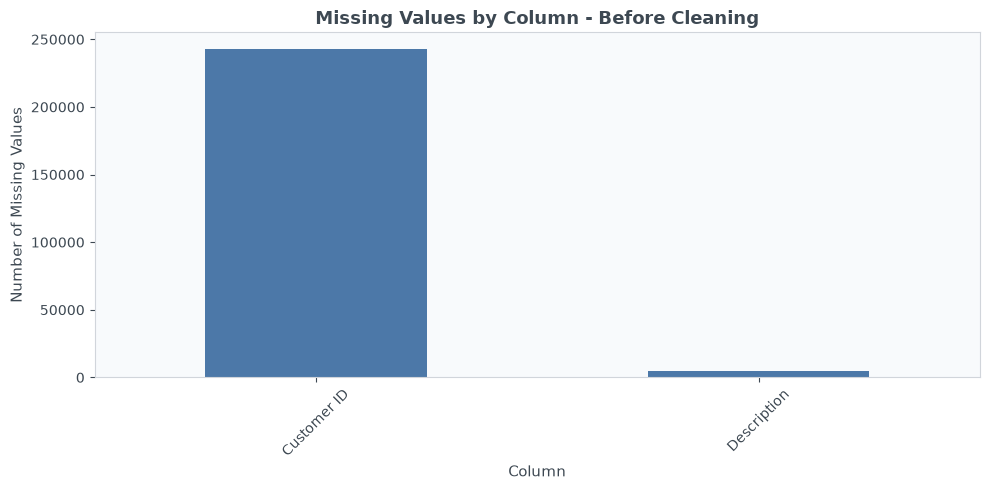

In [47]:
missing_values = df.isna().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 5))

missing_values.plot(
    kind="bar",
    color=COLORS["primary"]
)

plt.title("Missing Values by Column - Before Cleaning")
plt.xlabel("Column")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    plots_dir / "01_missing_values_before_cleaning.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

**Interpretation:**  
The dataset contains missing values in several columns. The `Customer ID` column has the largest number of missing values, with 243,007 transactions missing a customer identifier. This is important because customer-level behavioral analysis requires a valid customer ID. Other missing values, such as those in `Description`, will be handled according to their relevance to the analysis.

### 2. Quantity Distribution

This histogram shows the distribution of the `Quantity` variable before data cleaning.

**Why this graph?**  
A histogram is suitable for numerical variables because it shows how observations are distributed across different value ranges. It helps identify the typical quantity range, skewness, extreme values, and potential data-quality issues.

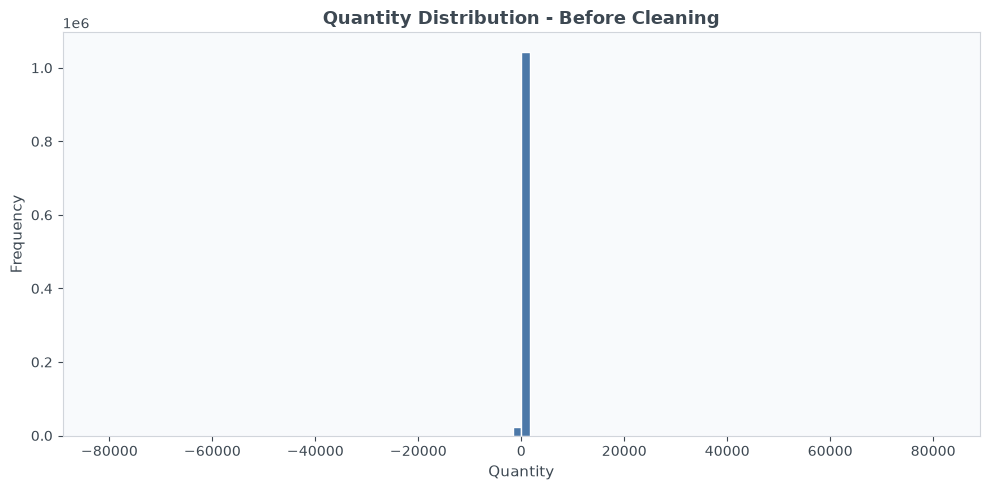

In [48]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["Quantity"].dropna(),
    bins=100,
    color=COLORS["primary"],
    edgecolor="white"
)

plt.title("Quantity Distribution - Before Cleaning")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    plots_dir / "02_quantity_distribution_before_cleaning.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

**Interpretation:**  
The `Quantity` distribution is highly concentrated around relatively small values, with a long right tail representing unusually large quantities. The dataset also contains 22,950 negative quantity observations, which may represent returns or cancellations and therefore require investigation during the data-cleaning stage.

### 3. Quantity Boxplot

This boxplot summarizes the distribution of the `Quantity` variable and highlights its spread and extreme observations before data cleaning.

**Why this graph?**  
A boxplot is useful for identifying potential outliers and understanding the central tendency and spread of a numerical variable. It provides a compact view of the median, interquartile range, and extreme observations.

C:\Users\HP\AppData\Local\Temp\ipykernel_14976\3434778309.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


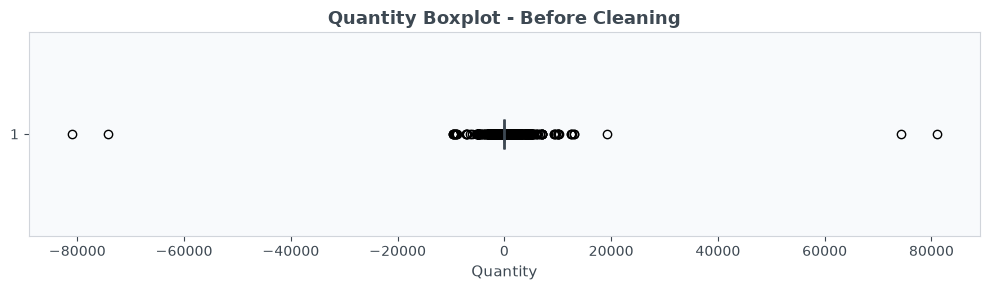

In [49]:
plt.figure(figsize=(10, 3))

plt.boxplot(
    df["Quantity"].dropna(),
    vert=False,
    patch_artist=True,
    boxprops=dict(
        facecolor=COLORS["secondary"],
        color=COLORS["dark"]
    ),
    medianprops=dict(
        color=COLORS["dark"],
        linewidth=2
    ),
    whiskerprops=dict(
        color=COLORS["dark"]
    ),
    capprops=dict(
        color=COLORS["dark"]
    )
)

plt.title("Quantity Boxplot - Before Cleaning")
plt.xlabel("Quantity")

plt.tight_layout()

plt.savefig(
    plots_dir / "03_quantity_boxplot_before_cleaning.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

**Interpretation:**  
The boxplot shows a wide spread in `Quantity` with numerous extreme observations, particularly on the higher end. The presence of negative values and extreme quantities indicates that the variable contains observations that require further investigation during the cleaning stage.

### 4. Price Distribution

This histogram shows the distribution of the `Price` variable before data cleaning.

**Why this graph?**  
A histogram is appropriate for numerical variables because it shows how values are distributed across different ranges. It helps identify the typical price range, skewness, and unusual values that may require further investigation during data cleaning.

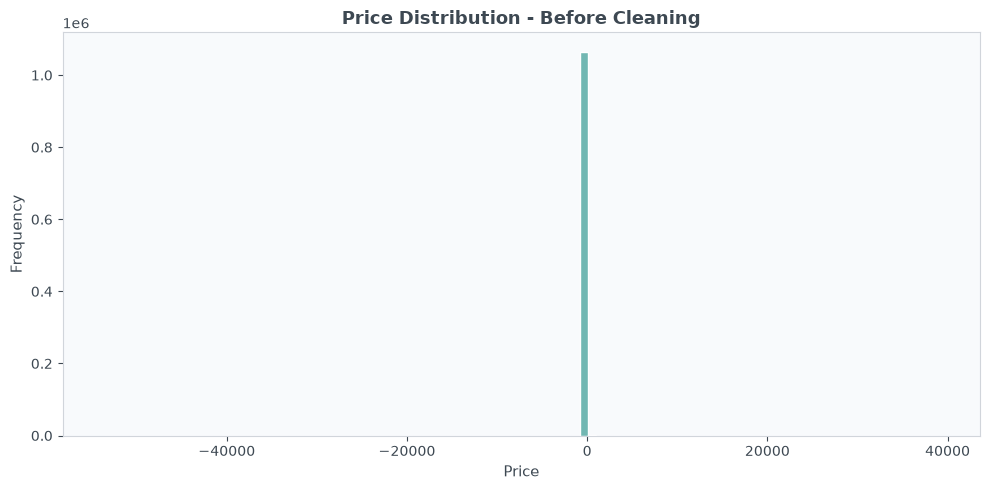

In [50]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["Price"].dropna(),
    bins=100,
    color=COLORS["secondary"],
    edgecolor="white"
)

plt.title("Price Distribution - Before Cleaning")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    plots_dir / "04_price_distribution_before_cleaning.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

**Interpretation:**  
The `Price` variable is highly right-skewed, with most observations concentrated at relatively low values and a long tail toward higher prices. The profiling also identified 6,202 zero-price observations and no negative prices. The zero-price observations will be investigated during the data-cleaning stage.

### 5. Price Boxplot

This boxplot summarizes the distribution of the `Price` variable and highlights extreme observations before data cleaning.

**Why this graph?**  
A boxplot is useful for identifying potential outliers and understanding the spread of a numerical variable. It provides a clear view of the median, interquartile range, and extreme price values.

C:\Users\HP\AppData\Local\Temp\ipykernel_14976\3291578102.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


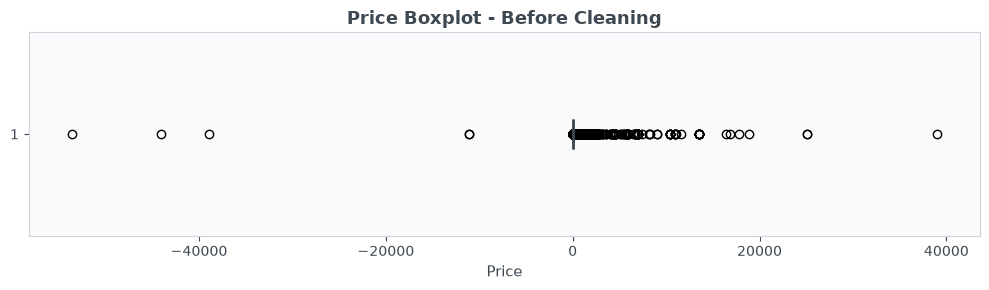

In [51]:
plt.figure(figsize=(10, 3))

plt.boxplot(
    df["Price"].dropna(),
    vert=False,
    patch_artist=True,
    boxprops=dict(
        facecolor=COLORS["primary"],
        color=COLORS["dark"]
    ),
    medianprops=dict(
        color=COLORS["dark"],
        linewidth=2
    ),
    whiskerprops=dict(
        color=COLORS["dark"]
    ),
    capprops=dict(
        color=COLORS["dark"]
    )
)

plt.title("Price Boxplot - Before Cleaning")
plt.xlabel("Price")

plt.tight_layout()

plt.savefig(
    plots_dir / "05_price_boxplot_before_cleaning.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

**Interpretation:**  
The boxplot shows a strongly right-skewed distribution with several extreme price observations. These unusually high values may disproportionately affect customer-level spending calculations and therefore should be investigated during the data-cleaning stage.

### 6. Transaction Activity Over Time

This line chart shows the number of transactions recorded across the observed period before data cleaning.

**Why this graph?**  
A line chart is appropriate for time-series data because it clearly shows changes in transaction activity over time. This is particularly relevant to our project because customer behavior will later be analyzed at the monthly level.

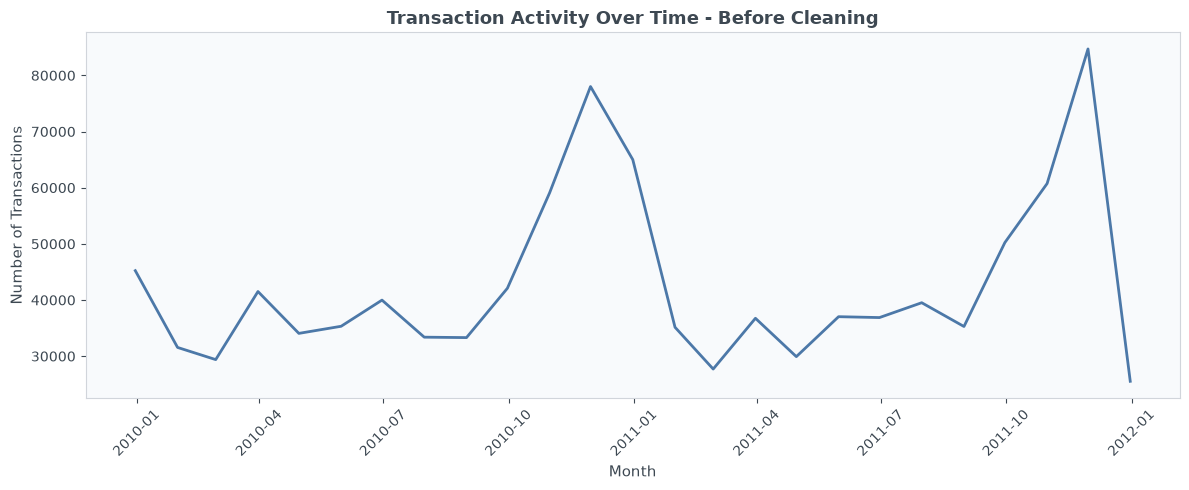

In [52]:
# Ensure InvoiceDate is in datetime format
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Calculate monthly transaction counts
monthly_transactions = (
    df.set_index("InvoiceDate")
    .resample("ME")
    .size()
)

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_transactions.index,
    monthly_transactions.values,
    color=COLORS["primary"],
    linewidth=2
)

plt.title("Transaction Activity Over Time - Before Cleaning")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    plots_dir / "06_transactions_over_time_before_cleaning.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

**Interpretation:**  
Transaction activity varies across the observed period, with noticeable changes between months. Examining the temporal distribution is important for understanding the dataset structure and supports the use of monthly customer-level behavioral analysis and chronological train, validation, and test splits.